In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import json
import re

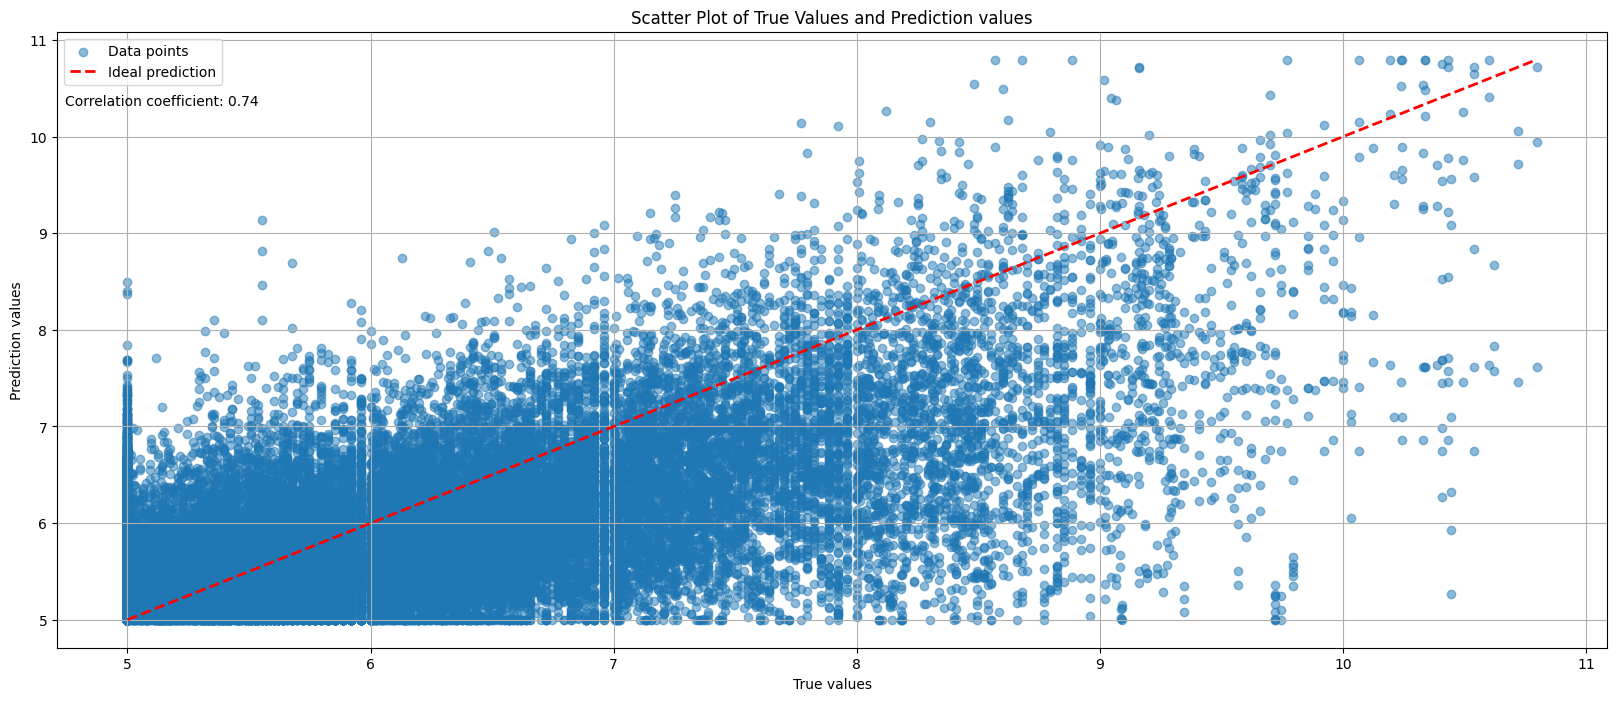

In [ ]:
# Scatter plot of true values and prediction values
file_path = '/Users/mikkohapponen/Documents/Tiedostot/Opiskelu/DI/Diplomityö/Data/Models/Results/predictions_davis.csv'
df = pd.read_csv(file_path)
plt.figure(figsize=(20, 8))
plt.scatter(df['True values'], df['Predictions'], alpha=0.5, label='Data points')
plt.plot([df['True values'].min(), df['True values'].max()], 
         [df['True values'].min(), df['True values'].max()], 
         color='red', linestyle='dashed', linewidth=2, label='Ideal prediction')
plt.grid(True)
correlation = np.corrcoef(df['True values'], df['Predictions'])[0, 1]
plt.text(0.005, 0.88, f'Correlation coefficient: {correlation:.2f}', 
         transform=plt.gca().transAxes, fontsize=10, color='black')
plt.xlabel("True values")
plt.ylabel("Prediction values")
plt.title("Scatter Plot of True Values and Prediction values")
plt.legend()
plt.show()

In [3]:
# Compute mean and standard deviation
file_path = '/Users/mikkohapponen/Documents/Tiedostot/Opiskelu/DI/Diplomityö/Data/Models/Results/predictions_davis.csv'
df = pd.read_csv(file_path)
true_mean, true_std = df['True values'].mean(), df['True values'].std()
pred_mean, pred_std = df['Predictions'].mean(), df['Predictions'].std()
print(f"For true values, mean is {true_mean:.3f} and standard deviation is {true_std:.3f}")
print(f"For prediction values, mean is {pred_mean:.3f} and standard deviation is {pred_std:.3f}")

For true values, mean is 5.452 and standard deviation is 0.895
For prediction values, mean is 5.489 and standard deviation is 0.674


In [5]:
# Compute mean absolute error, mean squared error, root mean squared error, and r-squared error
file_path = '/Users/mikkohapponen/Documents/Tiedostot/Opiskelu/DI/Diplomityö/Data/Models/Results/predictions_davis.csv'
df = pd.read_csv(file_path)
true_values = df['True values']
predictions = df['Predictions']
mae = mean_absolute_error(true_values, predictions)
mse = mean_squared_error(true_values, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(true_values, predictions)
print(f"MAE is {mae:.3f}")
print(f"MSE is {mse:.3f}")
print(f"RMSE is {rmse:.3f}")
print(f"R-squared is {r2:.3f}")

MAE is 0.364
MSE is 0.359
RMSE is 0.599
R-squared is 0.552


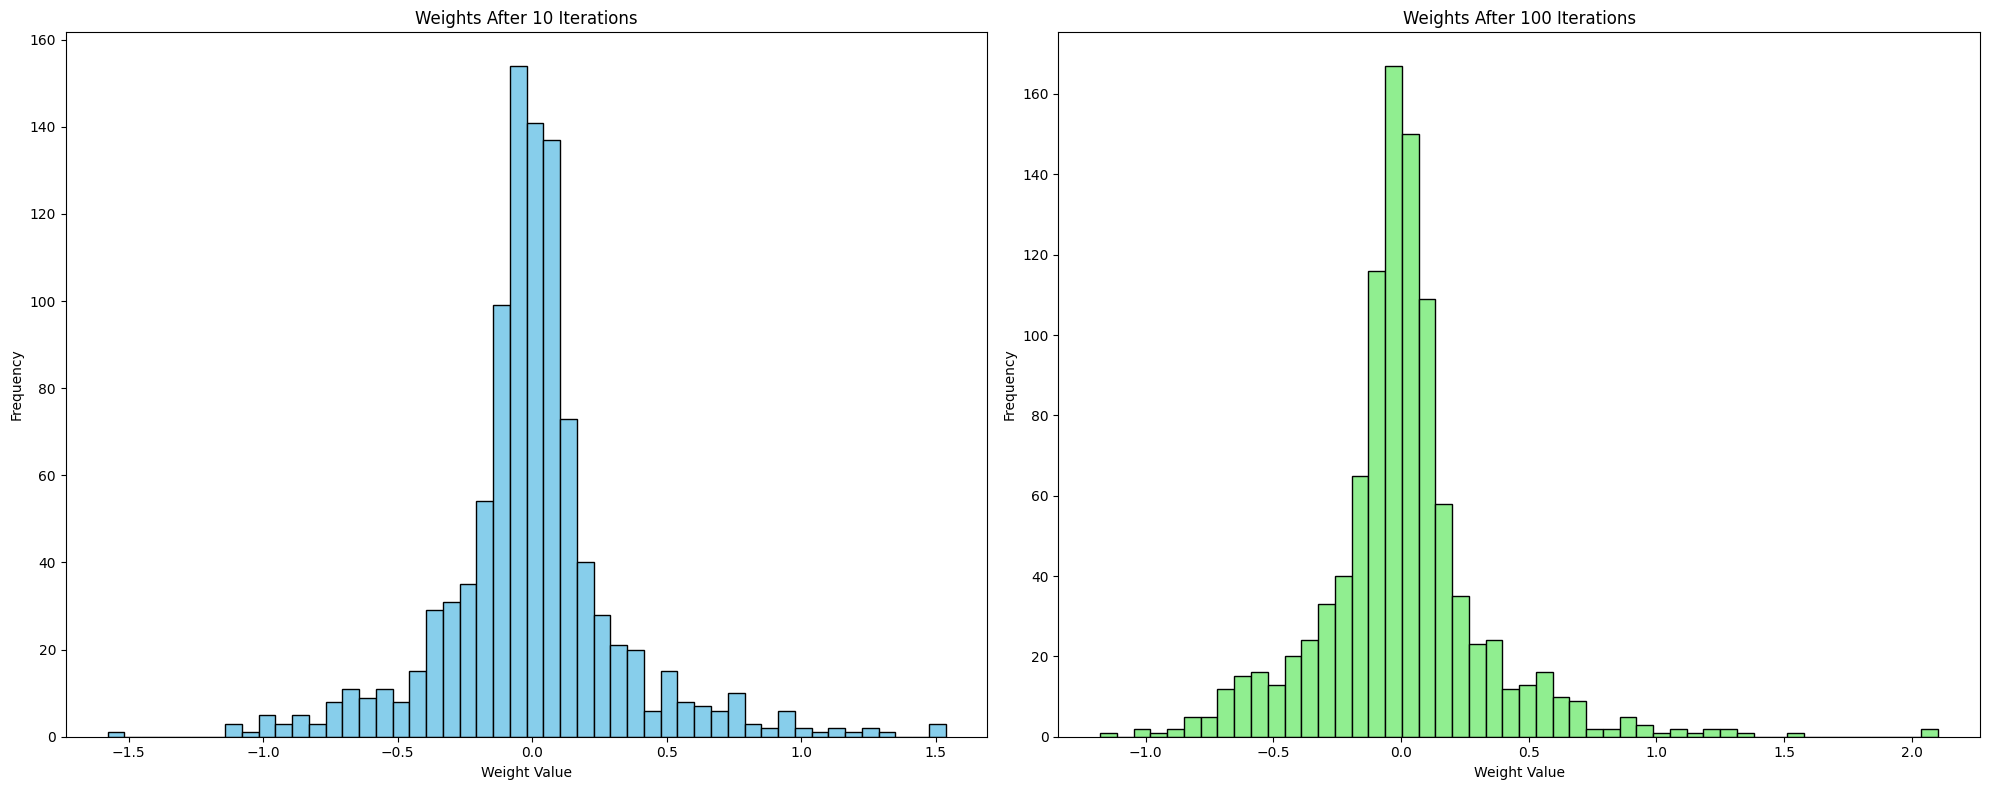

In [ ]:
# Plot histograms of weight distributions for different iterations
with open("weights_davis_both_10iterations.json", "r") as f1:
    data_early = json.load(f1)
with open("weights_davis_both_100iterations.json", "r") as f2:
    data_late = json.load(f2)
w_early = np.array(data_early["weights (w)"])
w_late = np.array(data_late["weights (w)"])
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.hist(w_early, bins=50, color='skyblue', edgecolor='black')
plt.title("Weights After 10 Iterations")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.subplot(1, 2, 2)
plt.hist(w_late, bins=50, color='lightgreen', edgecolor='black')
plt.title("Weights After 100 Iterations")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

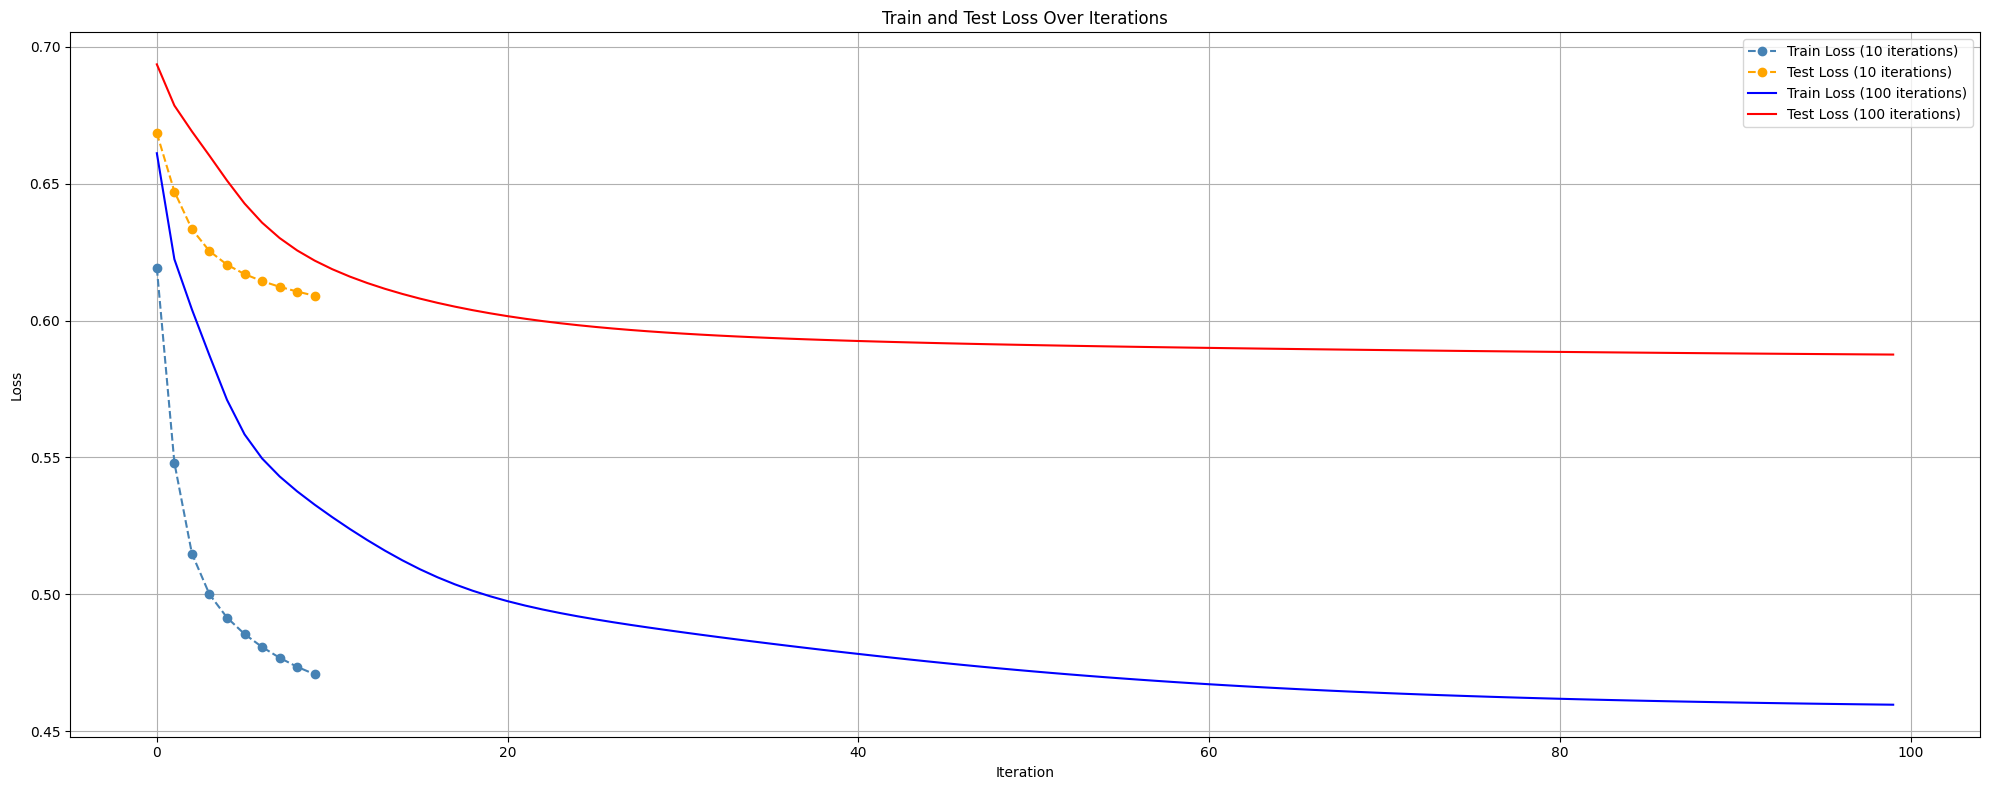

In [3]:
# Log outputs
log_10 = """
#Iter=  0	Train=0.619215	Test=0.668475
#Iter=  1	Train=0.548081	Test=0.647162
#Iter=  2	Train=0.514883	Test=0.633396
#Iter=  3	Train=0.500018	Test=0.625399
#Iter=  4	Train=0.491514	Test=0.62043
#Iter=  5	Train=0.485502	Test=0.616998
#Iter=  6	Train=0.480767	Test=0.614424
#Iter=  7	Train=0.476828	Test=0.612358
#Iter=  8	Train=0.473529	Test=0.610618
#Iter=  9	Train=0.470805	Test=0.609079
"""
log_100 = """
#Iter=  0	Train=0.661148	Test=0.693615
#Iter=  1	Train=0.622431	Test=0.678573
#Iter=  2	Train=0.604079	Test=0.669119
#Iter=  3	Train=0.587291	Test=0.660246
#Iter=  4	Train=0.571058	Test=0.651176
#Iter=  5	Train=0.558456	Test=0.642783
#Iter=  6	Train=0.549646	Test=0.635786
#Iter=  7	Train=0.543082	Test=0.630169
#Iter=  8	Train=0.537629	Test=0.625641
#Iter=  9	Train=0.532753	Test=0.621919
#Iter= 10	Train=0.52821	Test=0.618788
#Iter= 11	Train=0.523898	Test=0.616094
#Iter= 12	Train=0.519825	Test=0.613731
#Iter= 13	Train=0.515989	Test=0.611631
#Iter= 14	Train=0.512433	Test=0.609745
#Iter= 15	Train=0.509179	Test=0.608042
#Iter= 16	Train=0.506251	Test=0.606498
#Iter= 17	Train=0.503646	Test=0.605098
#Iter= 18	Train=0.501343	Test=0.603827
#Iter= 19	Train=0.499309	Test=0.602674
#Iter= 20	Train=0.49751	Test=0.601629
#Iter= 21	Train=0.495907	Test=0.600682
#Iter= 22	Train=0.49447	Test=0.599823
#Iter= 23	Train=0.493169	Test=0.599045
#Iter= 24	Train=0.491978	Test=0.598339
#Iter= 25	Train=0.490875	Test=0.597698
#Iter= 26	Train=0.489839	Test=0.597116
#Iter= 27	Train=0.488856	Test=0.596586
#Iter= 28	Train=0.487918	Test=0.596103
#Iter= 29	Train=0.487014	Test=0.595662
#Iter= 30	Train=0.486129	Test=0.595258
#Iter= 31	Train=0.485269	Test=0.594887
#Iter= 32	Train=0.484425	Test=0.594545
#Iter= 33	Train=0.4836	Test=0.594231
#Iter= 34	Train=0.482791	Test=0.593939
#Iter= 35	Train=0.481997	Test=0.593668
#Iter= 36	Train=0.481218	Test=0.593415
#Iter= 37	Train=0.480453	Test=0.593179
#Iter= 38	Train=0.4797	Test=0.592957
#Iter= 39	Train=0.478961	Test=0.592749
#Iter= 40	Train=0.478238	Test=0.592553
#Iter= 41	Train=0.477526	Test=0.592368
#Iter= 42	Train=0.476829	Test=0.592193
#Iter= 43	Train=0.476147	Test=0.592027
#Iter= 44	Train=0.475481	Test=0.591869
#Iter= 45	Train=0.474831	Test=0.591718
#Iter= 46	Train=0.474199	Test=0.591575
#Iter= 47	Train=0.473584	Test=0.591437
#Iter= 48	Train=0.472988	Test=0.591305
#Iter= 49	Train=0.472409	Test=0.591179
#Iter= 50	Train=0.471848	Test=0.591057
#Iter= 51	Train=0.471304	Test=0.59094
#Iter= 52	Train=0.470777	Test=0.590826
#Iter= 53	Train=0.470268	Test=0.590717
#Iter= 54	Train=0.469775	Test=0.590611
#Iter= 55	Train=0.469301	Test=0.590508
#Iter= 56	Train=0.468843	Test=0.590409
#Iter= 57	Train=0.468401	Test=0.590312
#Iter= 58	Train=0.467973	Test=0.590218
#Iter= 59	Train=0.467562	Test=0.590126
#Iter= 60	Train=0.467166	Test=0.590036
#Iter= 61	Train=0.466785	Test=0.589948
#Iter= 62	Train=0.466418	Test=0.589863
#Iter= 63	Train=0.466065	Test=0.589779
#Iter= 64	Train=0.465727	Test=0.589697
#Iter= 65	Train=0.465401	Test=0.589617
#Iter= 66	Train=0.465089	Test=0.589538
#Iter= 67	Train=0.464789	Test=0.589461
#Iter= 68	Train=0.464501	Test=0.589385
#Iter= 69	Train=0.464226	Test=0.589311
#Iter= 70	Train=0.463962	Test=0.589238
#Iter= 71	Train=0.463709	Test=0.589166
#Iter= 72	Train=0.463467	Test=0.589095
#Iter= 73	Train=0.463235	Test=0.589026
#Iter= 74	Train=0.463013	Test=0.588957
#Iter= 75	Train=0.462799	Test=0.58889
#Iter= 76	Train=0.462593	Test=0.588824
#Iter= 77	Train=0.462397	Test=0.588759
#Iter= 78	Train=0.462209	Test=0.588695
#Iter= 79	Train=0.462029	Test=0.588632
#Iter= 80	Train=0.461857	Test=0.58857
#Iter= 81	Train=0.461693	Test=0.58851
#Iter= 82	Train=0.461536	Test=0.58845
#Iter= 83	Train=0.461386	Test=0.588392
#Iter= 84	Train=0.461242	Test=0.588335
#Iter= 85	Train=0.461105	Test=0.588279
#Iter= 86	Train=0.460974	Test=0.588223
#Iter= 87	Train=0.460849	Test=0.588169
#Iter= 88	Train=0.460729	Test=0.588116
#Iter= 89	Train=0.460615	Test=0.588064
#Iter= 90	Train=0.460505	Test=0.588013
#Iter= 91	Train=0.4604	Test=0.587963
#Iter= 92	Train=0.460298	Test=0.587914
#Iter= 93	Train=0.4602	Test=0.587866
#Iter= 94	Train=0.460106	Test=0.587819
#Iter= 95	Train=0.460017	Test=0.587774
#Iter= 96	Train=0.459931	Test=0.587729
#Iter= 97	Train=0.459848	Test=0.587685
#Iter= 98	Train=0.459769	Test=0.587642
#Iter= 99	Train=0.459693	Test=0.5876
"""

# Plot train and test loss curves for different iterations
def parse_log(log_str):
    train, test = [], []
    for line in log_str.strip().splitlines():
        match = re.search(r'Train=([\d.]+)\s+Test=([\d.]+)', line)
        if match:
            train.append(float(match.group(1)))
            test.append(float(match.group(2)))
    return train, test
train_loss_10, test_loss_10 = parse_log(log_10)
train_loss_100, test_loss_100 = parse_log(log_100)
plt.figure(figsize=(20, 8))
plt.plot(train_loss_10, label='Train Loss (10 iterations)', marker='o', linestyle='--', color='steelblue')
plt.plot(test_loss_10, label='Test Loss (10 iterations)', marker='o', linestyle='--', color='orange')
plt.plot(train_loss_100, label='Train Loss (100 iterations)', color='blue')
plt.plot(test_loss_100, label='Test Loss (100 iterations)', color='red')
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Train and Test Loss Over Iterations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()